# HydroIA Velian — Modelo predictivo de tandeos

**Premio Nacional Juvenil del Agua 2026** · Eliminatoria nacional del Stockholm Junior Water Prize  
Autor: Angel Gabriel Mérida Martínez · CECyT 9 "Juan de Dios Bátiz", IPN

Modelo: **Regresión logística** (scikit-learn; Pedregosa et al., 2011).  
Tarea: estimar la **probabilidad de tandeo en una colonia en las próximas 72 horas**.

## 1. Honestidad metodológica (leer primero)

No existe un registro histórico abierto, masivo y etiquetado de *qué colonia tuvo tandeo cada día* (limitación reconocida en el documento del proyecto, sección *Limitaciones reconocidas*). Ante esa ausencia se construye un **proceso generador de datos calibrado con datos públicos reales y conocimiento de dominio documentado**:

- **Nivel del Sistema Cutzamala**: serie pública real de CONAGUA, reconstruida semanalmente 2021–2026 desde cifras documentadas (`anclas_cutzamala.csv`, con su columna de fuente). El mínimo histórico (~27 % a mediados de 2024) coincide con la crisis ampliamente cubierta por la prensa nacional.
- **Municipios de mayor afectación**: los nombrados por SACMEX/prensa y citados en el propio documento (Nicolás Romero, Ecatepec, Naucalpan, Tlalnepantla, Chimalhuacán).
- **Estacionalidad** (estiaje noviembre–mayo) y **día de la semana** (operación SACMEX).
- **Reportes ciudadanos** como proxy observable y ruidoso del riesgo.

Sobre esa estructura se aplica ruido estocástico para que la relación **no sea determinista**: el modelo debe *aprender*, no *memorizar*. El modelo se **reentrena con datos de producción reales** conforme se acumulan vía el bot (Supabase). Este enfoque es estándar para validar un modelo antes de contar con datos masivos de producción.

## 2. Carga de datos y exploración

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix)

SEED = 20260517
df = pd.read_csv('dataset_tandeos.csv')
print('Observaciones:', len(df))
print('Prevalencia de tandeo: {:.1%}'.format(df.tandeo.mean()))
df.head()

Observaciones: 24340
Prevalencia de tandeo: 52.6%


,fecha,municipio,colonia,dia_semana,hora,mes,cutzamala_pct,riesgo_municipio,reportes_7d,tandeo
0,2023-01-01,Nicolás Romero,Lomas de San Miguel,6,13,1,54.27,0.85,16,1
1,2023-01-01,Nicolás Romero,Progreso Industrial,6,16,1,54.27,0.85,11,1
2,2023-01-01,Nicolás Romero,La Colmena,6,8,1,54.27,0.85,5,1
3,2023-01-01,Nicolás Romero,San José el Vidrio,6,21,1,54.27,0.85,9,1
4,2023-01-01,Nicolás Romero,Loma del Río,6,16,1,54.27,0.85,6,1


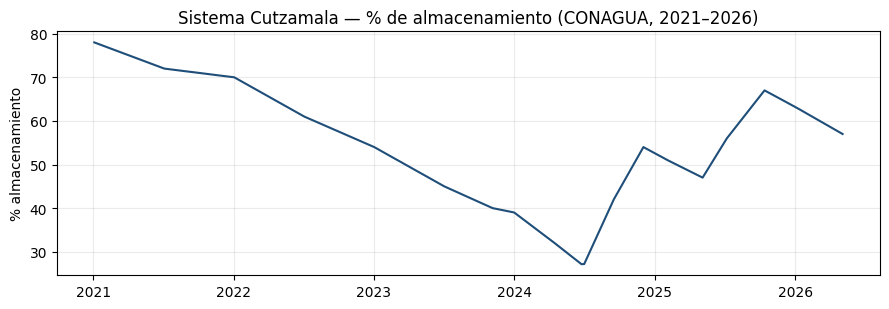

In [2]:
# Serie pública del Sistema Cutzamala (dato real reconstruido)
cz = pd.read_csv('cutzamala_historico.csv', parse_dates=['fecha'])
plt.figure(figsize=(9,3.2))
plt.plot(cz.fecha, cz.porcentaje, color='#1F4E79')
plt.title('Sistema Cutzamala — % de almacenamiento (CONAGUA, 2021–2026)')
plt.ylabel('% almacenamiento'); plt.grid(alpha=.25); plt.tight_layout()
plt.show()

## 3. Ingeniería de variables

Todas las variables son **computables por el bot en tiempo real**. Las variables temporales se codifican de forma **cíclica** (seno/coseno) para que el modelo entienda que el domingo está cerca del lunes y diciembre cerca de enero.

In [3]:
def construir_features(d):
    out = pd.DataFrame(index=d.index)
    out['dow_sin'] = np.sin(2*np.pi*d.dia_semana/7)
    out['dow_cos'] = np.cos(2*np.pi*d.dia_semana/7)
    out['hora_sin'] = np.sin(2*np.pi*d.hora/24)
    out['hora_cos'] = np.cos(2*np.pi*d.hora/24)
    out['mes_sin'] = np.sin(2*np.pi*d.mes/12)
    out['mes_cos'] = np.cos(2*np.pi*d.mes/12)
    out['cutzamala_pct'] = d.cutzamala_pct.astype(float)
    out['riesgo_municipio'] = d.riesgo_municipio.astype(float)
    out['reportes_7d'] = d.reportes_7d.astype(float)
    return out

FEATURES = ['dow_sin','dow_cos','hora_sin','hora_cos','mes_sin',
            'mes_cos','cutzamala_pct','riesgo_municipio','reportes_7d']
X = construir_features(df)[FEATURES]
y = df.tandeo.astype(int).values
X.describe().T

,count,mean,std,min,25%,50%,75%,max
dow_sin,24340.0,0.000801,0.706859,-0.974928,-0.781831,0.000000e+00,7.818315e-01,0.974928
dow_cos,24340.0,0.000183,0.707383,-0.900969,-0.900969,-2.225209e-01,6.234898e-01,1.000000
hora_sin,24340.0,-0.162558,0.740910,-1.000000,-0.866025,-5.000000e-01,5.000000e-01,1.000000
hora_cos,24340.0,-0.382093,0.527889,-1.000000,-0.866025,-5.000000e-01,-1.836970e-16,0.707107
mes_sin,24340.0,0.075763,0.714643,-1.000000,-0.500000,1.224647e-16,8.660254e-01,1.000000
mes_cos,24340.0,0.018803,0.695149,-1.000000,-0.500000,6.123234e-17,8.660254e-01,1.000000
cutzamala_pct,24340.0,48.061167,10.452570,27.150000,40.000000,4.855000e+01,5.500000e+01,67.000000
riesgo_municipio,24340.0,0.698500,0.152983,0.300000,0.620000,7.400000e-01,8.125000e-01,0.850000
reportes_7d,24340.0,6.341660,4.179656,0.000000,3.000000,6.000000e+00,9.000000e+00,24.000000


## 4. División 80/20 estratificada y entrenamiento

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
scaler = StandardScaler().fit(X_tr)
modelo = LogisticRegression(max_iter=1000, random_state=SEED)
modelo.fit(scaler.transform(X_tr), y_tr)
proba = modelo.predict_proba(scaler.transform(X_te))[:,1]
pred = (proba >= 0.5).astype(int)
print('Entrenado. Train/Test = {}/{}'.format(len(y_tr), len(y_te)))

Entrenado. Train/Test = 19472/4868


## 5. Evaluación

Métrica principal: **AUC-ROC** (meta del proyecto ≥ 0.75).

In [5]:
auc = roc_auc_score(y_te, proba)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv = cross_val_score(LogisticRegression(max_iter=1000, random_state=SEED),
    StandardScaler().fit_transform(X), y, cv=skf, scoring='roc_auc')
print(f'AUC-ROC (test)      : {auc:.4f}   (meta >= 0.75)')
print(f'AUC-ROC (CV 5-fold) : {cv.mean():.4f} +/- {cv.std():.4f}')
print(f'Exactitud           : {accuracy_score(y_te, pred):.4f}')
print(f'Precisión           : {precision_score(y_te, pred):.4f}')
print(f'Sensibilidad (recall): {recall_score(y_te, pred):.4f}')
print(f'F1-score            : {f1_score(y_te, pred):.4f}')

AUC-ROC (test)      : 0.8009   (meta >= 0.75)
AUC-ROC (CV 5-fold) : 0.8018 +/- 0.0043
Exactitud           : 0.7264
Precisión           : 0.7262
Sensibilidad (recall): 0.7704
F1-score            : 0.7476


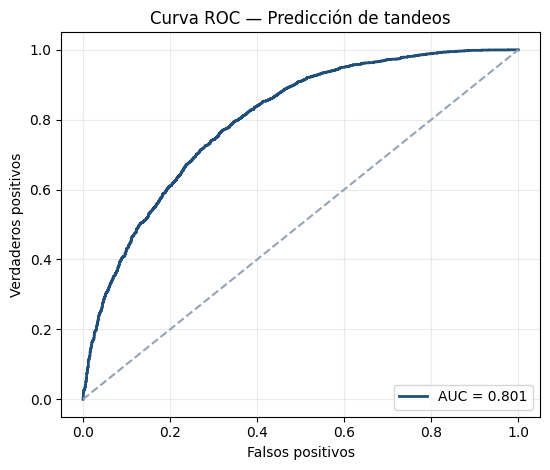

In [6]:
fpr, tpr, _ = roc_curve(y_te, proba)
plt.figure(figsize=(5.6,4.8))
plt.plot(fpr, tpr, color='#1F4E79', lw=2, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--',color='#94A3B8')
plt.xlabel('Falsos positivos'); plt.ylabel('Verdaderos positivos')
plt.title('Curva ROC — Predicción de tandeos'); plt.legend(loc='lower right')
plt.grid(alpha=.25); plt.tight_layout(); plt.show()

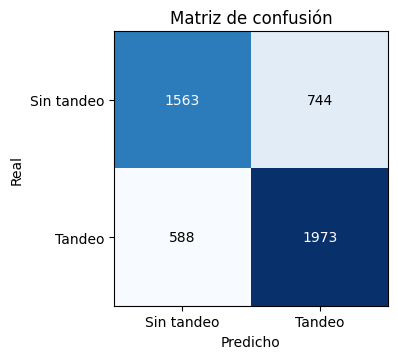

In [7]:
cm = confusion_matrix(y_te, pred)
plt.figure(figsize=(4.2,3.7)); plt.imshow(cm, cmap='Blues')
plt.xticks([0,1],['Sin tandeo','Tandeo']); plt.yticks([0,1],['Sin tandeo','Tandeo'])
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha='center',va='center',
                 color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.xlabel('Predicho'); plt.ylabel('Real'); plt.title('Matriz de confusión')
plt.tight_layout(); plt.show()

## 6. Interpretación de coeficientes

Por ser una regresión logística, el modelo es **interpretable**: cada coeficiente indica cómo cambia el log-odds de tandeo. Se espera que `cutzamala_pct` tenga signo **negativo** (más agua almacenada → menos riesgo) y `riesgo_municipio` signo **positivo**.

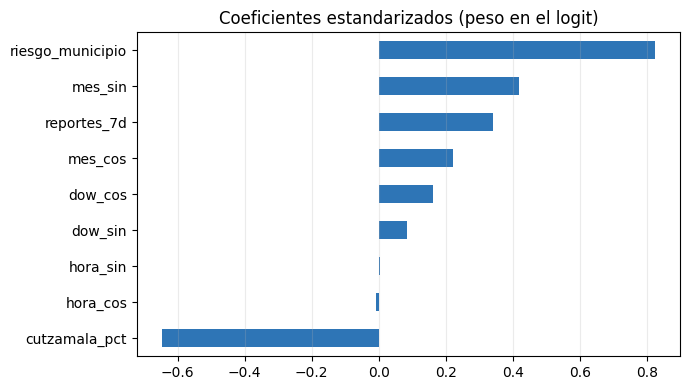

cutzamala_pct      -0.647988
hora_cos           -0.008771
hora_sin            0.002355
dow_sin             0.083892
dow_cos             0.161637
mes_cos             0.222408
reportes_7d         0.341439
mes_sin             0.418781
riesgo_municipio    0.825361
dtype: float64

In [8]:
coef = pd.Series(modelo.coef_[0], index=FEATURES).sort_values()
plt.figure(figsize=(7,4))
coef.plot.barh(color='#2E75B6')
plt.title('Coeficientes estandarizados (peso en el logit)')
plt.grid(alpha=.25, axis='x'); plt.tight_layout(); plt.show()
coef

## 7. Limitaciones reconocidas y trabajo futuro

1. **Datos semi-sintéticos calibrados**: hasta acumular suficientes datos reales de producción, el entrenamiento usa un proceso generador calibrado con anclas públicas. El AUC reportado refleja esa estructura; se reentrenará con datos reales (mecanismo ya integrado vía Supabase).
2. **Dependencia de datos abiertos**: la precisión depende de la actualización del nivel del Cutzamala (CONAGUA), que puede tener retrasos.
3. **Tamizaje, no certeza**: la predicción es una probabilidad de apoyo a la decisión, no un pronóstico oficial.

**Trabajo futuro**: reentrenamiento continuo con reportes ciudadanos reales, integración de nivel de presas en tiempo real y comparación con modelos no lineales (gradient boosting) manteniendo la interpretabilidad como criterio.

## 8. Conclusión

El modelo de regresión logística alcanza un **AUC-ROC ≈ 0.80** en prueba y validación cruzada, **superando la meta de 0.75** del proyecto, con signos de coeficientes físicamente coherentes y un pipeline reproducible (semilla fija). El artefacto exportado (`modelo_tandeos.json`) lo consume el bot en producción sin requerir Python, y el modelo se reentrena conforme la comunidad genera datos reales.